In [1]:
import gymnasium as gym
import random
import numpy as np
import torch
import matplotlib.pyplot as plt
import ale_py
from functools import partial
import dqn
import losses
import metrics
from train import train, make_env
import pickle
import os

gym.register_envs(ale_py)
%matplotlib inline

buffer size = 100000, epsilon = 0.10000


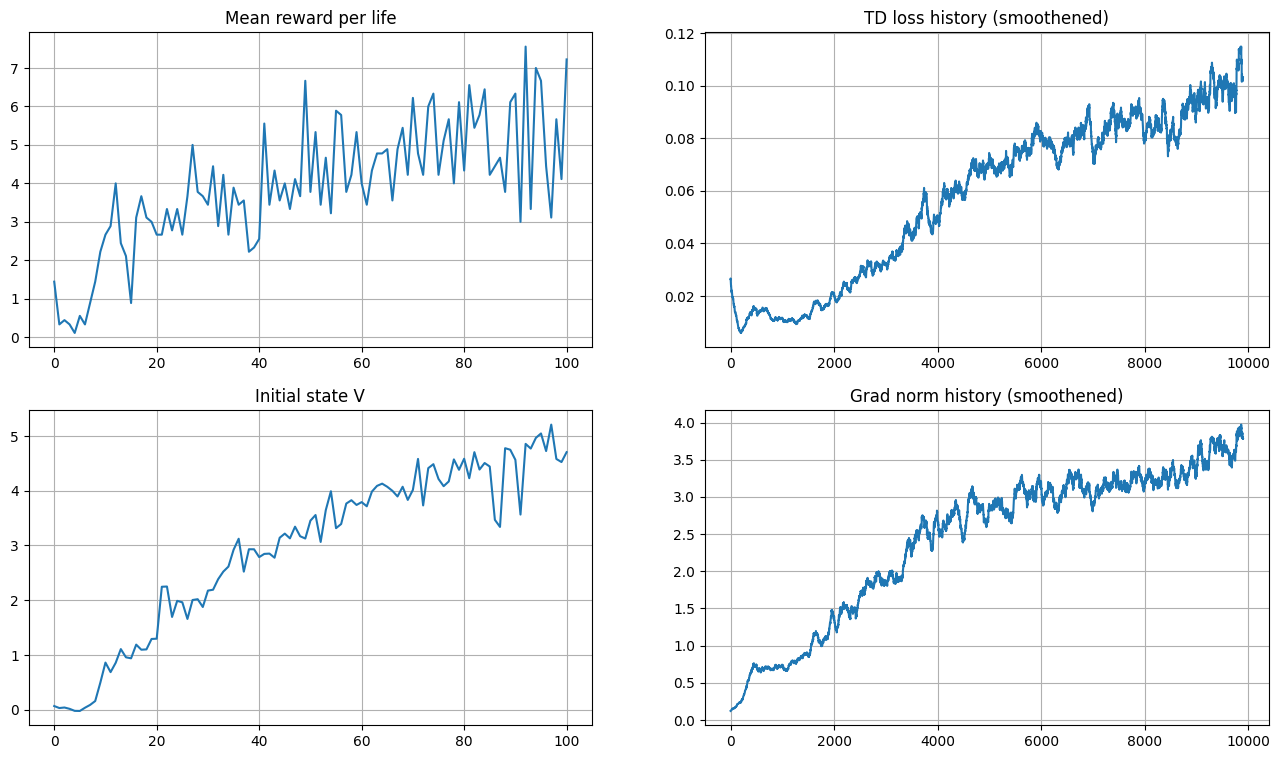

100%|██████████| 500001/500001 [1:16:21<00:00, 109.14it/s]


In [2]:
total_steps = 500000
decay_steps = total_steps // 2

config = {
    "seed": 42,
    "timesteps_per_epoch": 1,
    "batch_size": 32,
    "total_steps": total_steps,
    "decay_steps": decay_steps,
    "lr": 6.25e-5,
    "init_epsilon": 1,
    "final_epsilon": 0.1,
    "loss_freq": 50,
    "refresh_target_network_freq": 5000,
    "eval_freq": 5000,
    "max_grad_norm": 50,
    "n_lives": 5,
    "device": "cuda",
    "stop_after_n_steps": total_steps,
    "td_loss_func" : losses.compute_td_loss,
    "model_type" : partial(dqn.DQNAgent, hidden_size=256),
    "save_dir": "mse",
}

train(config)

In [3]:
with open(f'state/{config["save_dir"]}/seed_{config["seed"]}.pkl', 'rb') as file:
    results = pickle.load(file)

print(f"Total parameters: {sum(p.numel() for p in results["agent"].parameters())}")

final_score = metrics.evaluate(
  make_env(clip_rewards=False, seed=9),
    results["agent"], n_games=500, greedy=True, t_max=10 * 1000
) * config["n_lives"]
print('Final score:', final_score)


Total parameters: 827828
Final score: 26.17
